# DIP Lab 1, 2 (27 Sep, 2026)



In [1]:
import os
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import cv2


IMG = "images"         


os.makedirs("results", exist_ok=True)
print("Libraries loaded. Image folder:", IMG)


Libraries loaded. Image folder: images


## 1. Reading, Displaying, and Inspecting a Digital Image

--- COLOR (Nature): nature_color.png ---
  Width: 512, Height: 512, Channels: 3, dtype: uint8
  Data size (bytes): 786432
--- GRAYSCALE (Nature): nature_gray.png ---
  Width: 512, Height: 512, Channels: 1, dtype: uint8
  Data size (bytes): 262144

Differences:
  Color → 3 channels, ~3× data size
  Grayscale → 1 channel
  Both typically uint8 (8-bit unsigned)


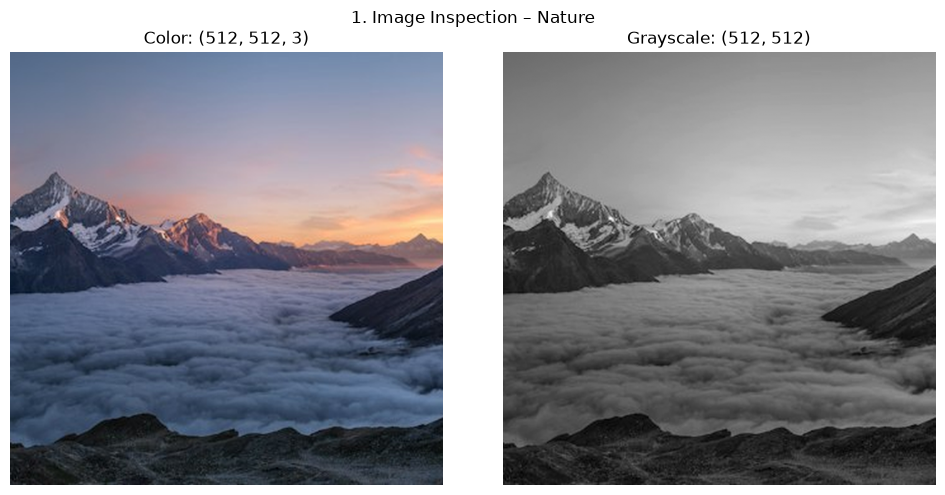

In [2]:
def inspect_image(path, label):
    im = Image.open(path)
    arr = np.array(im)
    if arr.ndim == 2:
        h, w = arr.shape
        channels = 1
    else:
        h, w, channels = arr.shape
    print(f"--- {label}: {os.path.basename(path)} ---")
    print(f"  Width: {w}, Height: {h}, Channels: {channels}, dtype: {arr.dtype}")
    print(f"  Data size (bytes): {arr.nbytes}")
    return arr

color_arr = inspect_image(os.path.join(IMG, "nature_color.png"), "COLOR (Nature)")
gray_arr  = inspect_image(os.path.join(IMG, "nature_gray.png"), "GRAYSCALE (Nature)")

print("\nDifferences:")
print("  Color → 3 channels, ~3× data size")
print("  Grayscale → 1 channel")
print("  Both typically uint8 (8-bit unsigned)")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(color_arr)
axes[0].set_title(f"Color: {color_arr.shape}")
axes[0].axis("off")
axes[1].imshow(gray_arr, cmap="gray")
axes[1].set_title(f"Grayscale: {gray_arr.shape}")
axes[1].axis("off")
plt.suptitle("1. Image Inspection – Nature")
plt.tight_layout()
plt.savefig("results/01_inspection.png", dpi=120, bbox_inches="tight")
plt.show()


## 2. Converting a Color Image to Grayscale

Original : shape=(512, 512, 3), bytes=786432
Grayscale: shape=(512, 512), bytes=262144
Channels 3 → 1 | Size reduced by factor of ~3


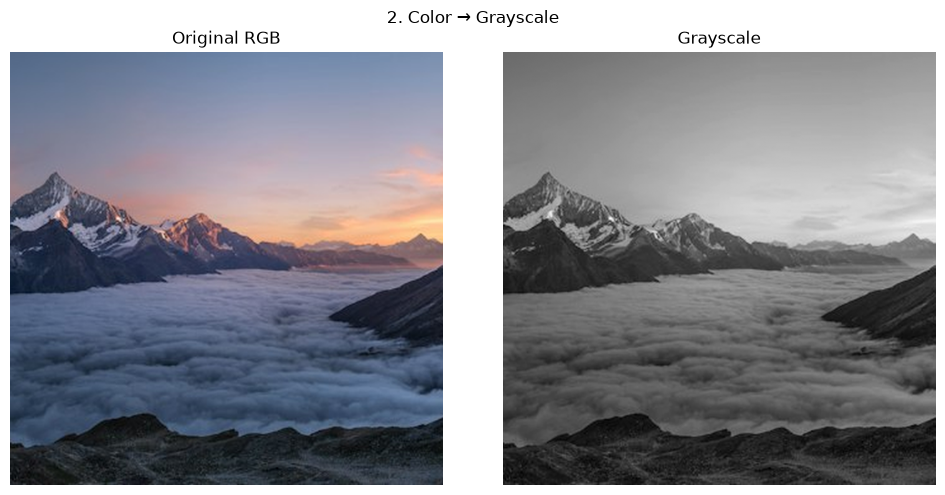

In [3]:
color = Image.open(os.path.join(IMG, "nature_color.png"))
color_arr = np.array(color)
gray = color.convert("L")
gray_arr = np.array(gray)

print(f"Original : shape={color_arr.shape}, bytes={color_arr.nbytes}")
print(f"Grayscale: shape={gray_arr.shape}, bytes={gray_arr.nbytes}")
print(f"Channels 3 → 1 | Size reduced by factor of ~3")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(color_arr); axes[0].set_title("Original RGB"); axes[0].axis("off")
axes[1].imshow(gray_arr, cmap="gray"); axes[1].set_title("Grayscale"); axes[1].axis("off")
plt.suptitle("2. Color → Grayscale")
plt.tight_layout()
plt.savefig("results/02_color_to_gray.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Classifying an Unknown Image

In [4]:
def classify_image(path):
    arr = np.array(Image.open(path))
    unique = np.unique(arr)
    n_unique = len(unique)
    channels = 1 if arr.ndim == 2 else arr.shape[2]
    if channels == 1:
        if n_unique <= 2:
            kind = "binary"
            reason = f"detected {n_unique} unique pixel values {unique.tolist()}, single channel"
        else:
            kind = "grayscale"
            reason = f"single channel, {n_unique} unique intensities (range {unique.min()}-{unique.max()})"
    else:
        kind = "full-color"
        reason = f"detected {channels} channels and many unique colors"
    print(f"{os.path.basename(path)}: {kind.upper()}")
    print(f"  Reasoning: {reason}")
    return kind

for f in ["nature_color.png", "nature_gray.png", "binary.png"]:
    classify_image(os.path.join(IMG, f))


nature_color.png: FULL-COLOR
  Reasoning: detected 3 channels and many unique colors
nature_gray.png: GRAYSCALE
  Reasoning: single channel, 234 unique intensities (range 1-240)
binary.png: BINARY
  Reasoning: detected 2 unique pixel values [0, 255], single channel


## 4. Surveying Imaging Modalities

X-ray: Medical diagnosis of bone fractures / chest
Satellite: Earth observation, weather, land-use mapping
Microscopy: Biological research, cell structure, pathology
Ultrasound: Obstetric imaging, soft-tissue examination
Infrared: Night vision, thermal / insulation inspection


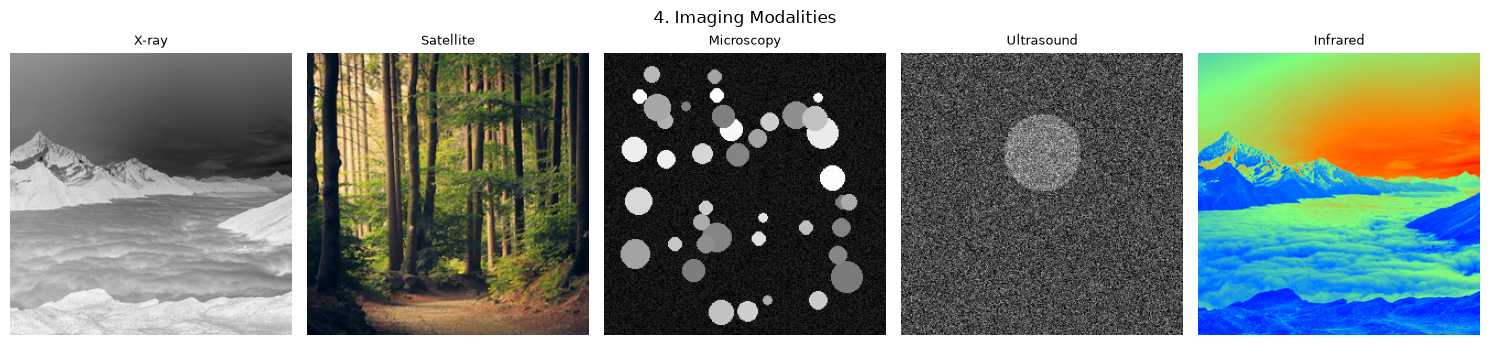

In [5]:
modalities = [
    ("xray_synth.png",       "X-ray",        "Medical diagnosis of bone fractures / chest"),
    ("satellite_synth.png",  "Satellite",    "Earth observation, weather, land-use mapping"),
    ("micro_synth.png",      "Microscopy",   "Biological research, cell structure, pathology"),
    ("ultrasound_synth.png", "Ultrasound",   "Obstetric imaging, soft-tissue examination"),
    ("infrared_synth.png",   "Infrared",     "Night vision, thermal / insulation inspection"),
]

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
for ax, (fname, mod, app) in zip(axes, modalities):
    arr = np.array(Image.open(os.path.join(IMG, fname)))
    ax.imshow(arr, cmap="gray" if arr.ndim == 2 else None)
    ax.set_title(mod, fontsize=9)
    ax.axis("off")
    print(f"{mod}: {app}")
plt.suptitle("4. Imaging Modalities")
plt.tight_layout()
plt.savefig("results/04_modalities.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Thresholding a Grayscale Image into Binary

T=50: white pixels = 219174
T=128: white pixels = 97158
T=200: white pixels = 4759


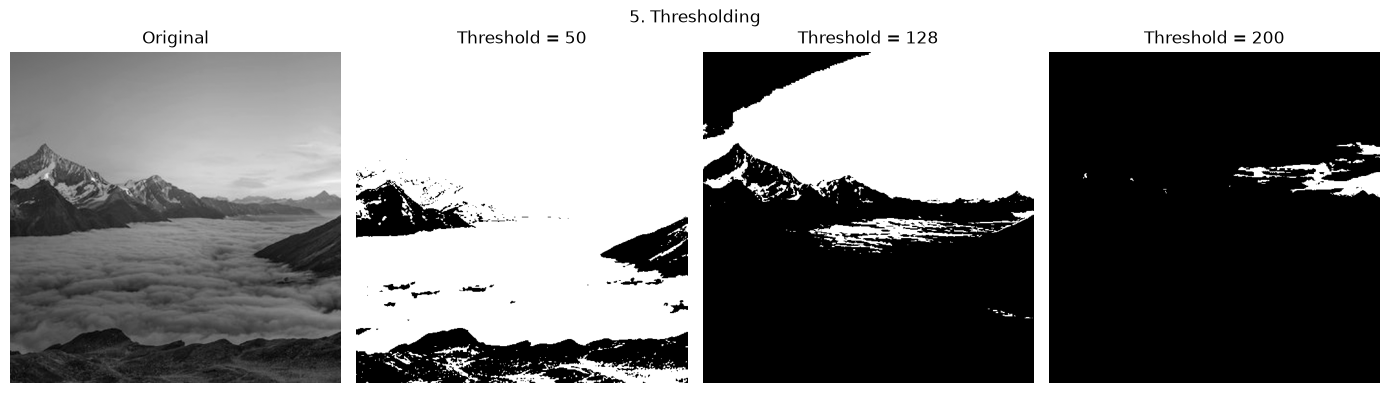

Lower T → more white; higher T → more black.


In [6]:
gray = np.array(Image.open(os.path.join(IMG, "nature_gray.png")))
thresholds = [50, 128, 200]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(gray, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
for i, t in enumerate(thresholds):
    binary = np.where(gray >= t, 255, 0).astype(np.uint8)
    axes[i+1].imshow(binary, cmap="gray")
    axes[i+1].set_title(f"Threshold = {t}")
    axes[i+1].axis("off")
    print(f"T={t}: white pixels = {np.sum(binary==255)}")
plt.suptitle("5. Thresholding")
plt.tight_layout()
plt.savefig("results/05_thresholding.png", dpi=120, bbox_inches="tight")
plt.show()
print("Lower T → more white; higher T → more black.")


## 6. Observing the Checkerboard Effect (Spatial Resolution)

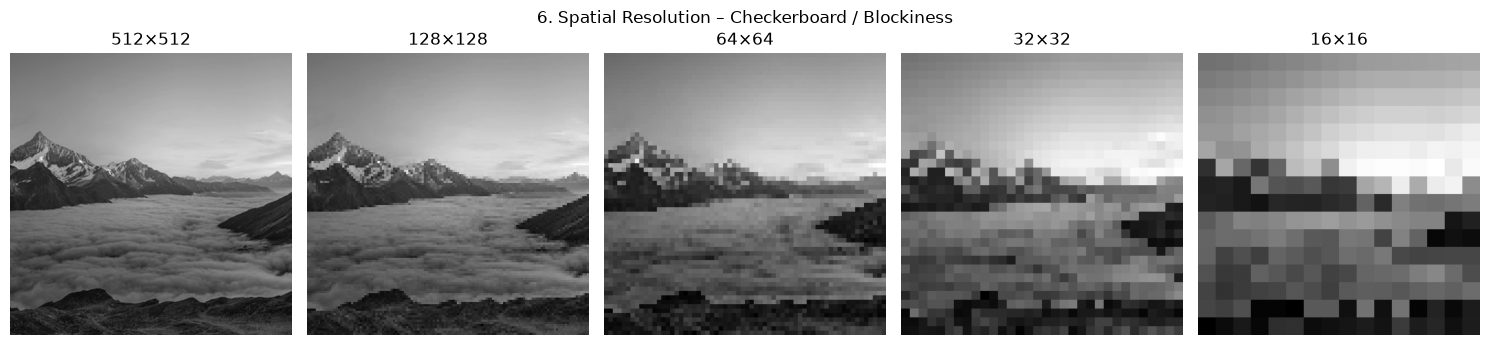

As resolution decreases, pixels become large uniform blocks.
Fine detail is lost and the image looks blocky (checkerboard effect).


In [7]:
orig = np.array(Image.open(os.path.join(IMG, "nature_gray.png")))
sizes = [128, 64, 32, 16]

fig, axes = plt.subplots(1, 5, figsize=(15, 3.5))
axes[0].imshow(orig, cmap="gray"); axes[0].set_title("512×512"); axes[0].axis("off")
for ax, s in zip(axes[1:], sizes):
    small = cv2.resize(orig, (s, s), interpolation=cv2.INTER_NEAREST)
    display = cv2.resize(small, (512, 512), interpolation=cv2.INTER_NEAREST)
    ax.imshow(display, cmap="gray")
    ax.set_title(f"{s}×{s}")
    ax.axis("off")
plt.suptitle("6. Spatial Resolution – Checkerboard / Blockiness")
plt.tight_layout()
plt.savefig("results/06_spatial_resolution.png", dpi=120, bbox_inches="tight")
plt.show()
print("""As resolution decreases, pixels become large uniform blocks.
Fine detail is lost and the image looks blocky (checkerboard effect).""")


## 7. Observing False Contouring (Intensity Resolution)

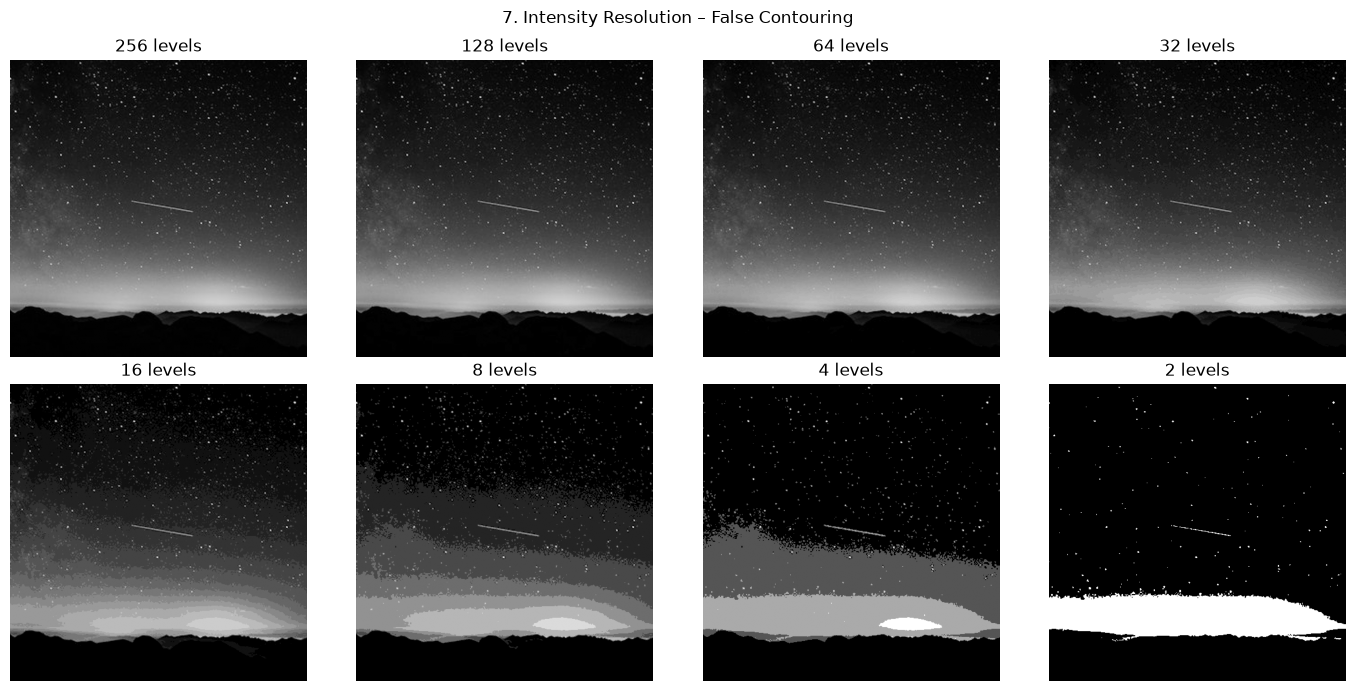

False contouring (banding) appears in smoothly shaded regions
when the number of gray levels is reduced. Most visible below ~32 levels.


In [8]:
sky = np.array(Image.open(os.path.join(IMG, "sky_gray.png"))).astype(np.float32)
levels_list = [256, 128, 64, 32, 16, 8, 4, 2]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for ax, nlev in zip(axes, levels_list):
    if nlev == 256:
        quant = sky.astype(np.uint8)
    else:
        quant = (np.floor(sky / 256.0 * nlev) * (256.0 / nlev)).clip(0, 255).astype(np.uint8)
    ax.imshow(quant, cmap="gray")
    ax.set_title(f"{nlev} levels")
    ax.axis("off")
plt.suptitle("7. Intensity Resolution – False Contouring")
plt.tight_layout()
plt.savefig("results/07_false_contouring.png", dpi=120, bbox_inches="tight")
plt.show()
print("""False contouring (banding) appears in smoothly shaded regions
when the number of gray levels is reduced. Most visible below ~32 levels.""")


## 8. Comparing Image Interpolation Methods

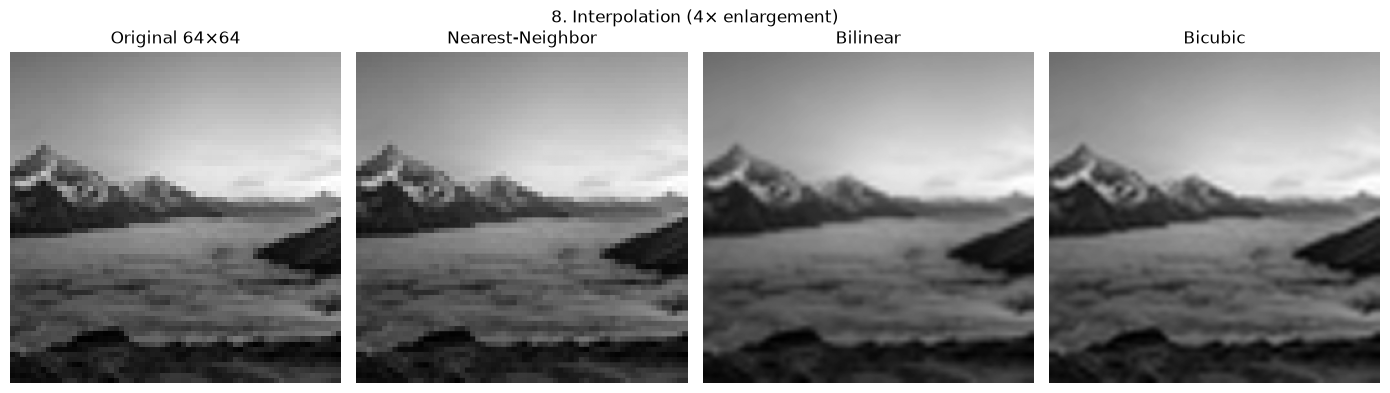

Nearest-neighbor → blocky
Bilinear → smoother but soft
Bicubic → smoothest, best edge preservation


In [9]:
small = np.array(Image.open(os.path.join(IMG, "small64.png")))
methods = [
    (cv2.INTER_NEAREST, "Nearest-Neighbor"),
    (cv2.INTER_LINEAR,  "Bilinear"),
    (cv2.INTER_CUBIC,   "Bicubic"),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(small, cmap="gray"); axes[0].set_title("Original 64×64"); axes[0].axis("off")
for ax, (interp, name) in zip(axes[1:], methods):
    large = cv2.resize(small, (256, 256), interpolation=interp)
    ax.imshow(large, cmap="gray")
    ax.set_title(name)
    ax.axis("off")
plt.suptitle("8. Interpolation (4× enlargement)")
plt.tight_layout()
plt.savefig("results/08_interpolation.png", dpi=120, bbox_inches="tight")
plt.show()
print("""Nearest-neighbor → blocky
Bilinear → smoother but soft
Bicubic → smoothest, best edge preservation""")


## 9. Computing and Interpreting an Image Histogram

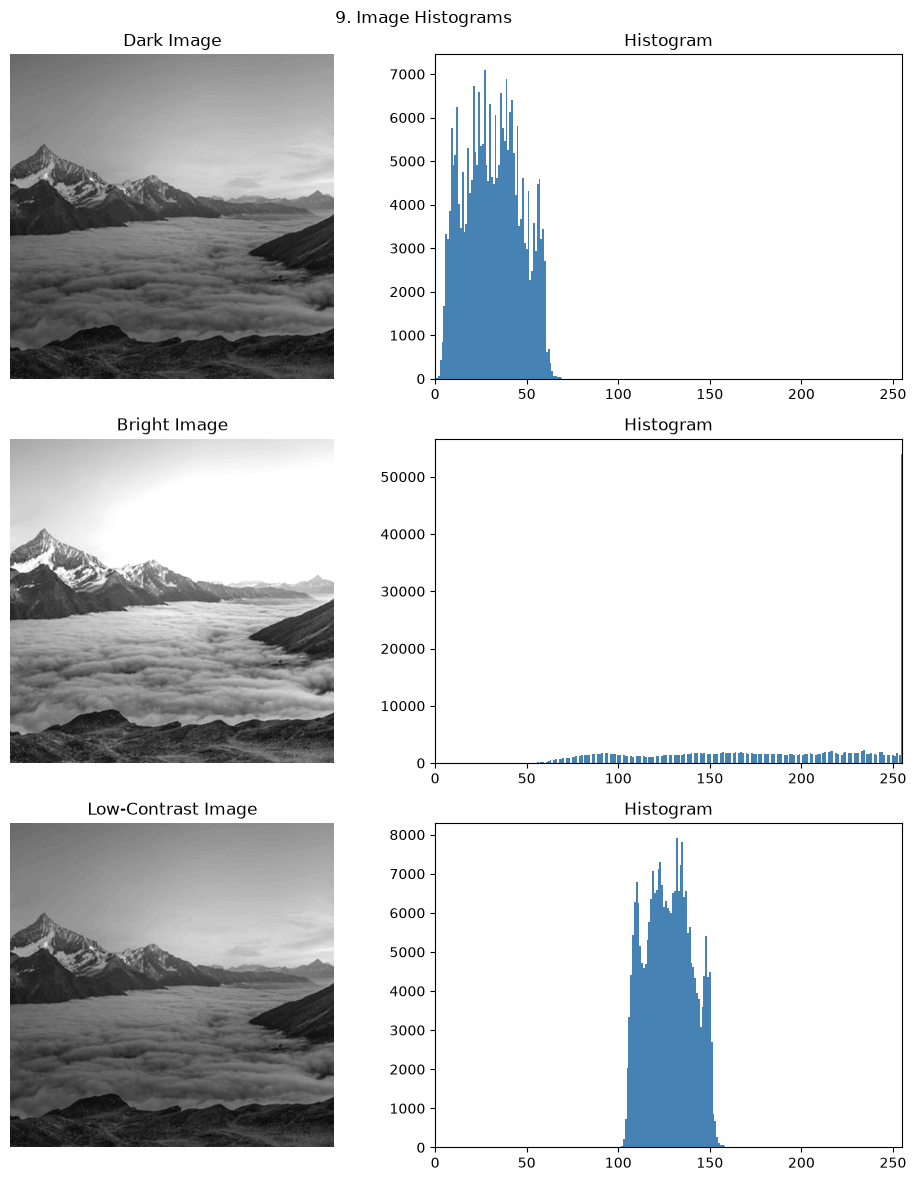

Dark → mass at low intensities
Bright → mass at high intensities
Low-contrast → narrow peak around mid-gray


In [10]:
def plot_hist(path, title, ax_img, ax_hist):
    arr = np.array(Image.open(path).convert("L"))
    ax_img.imshow(arr, cmap="gray")
    ax_img.set_title(title)
    ax_img.axis("off")
    hist, _ = np.histogram(arr.flatten(), bins=256, range=(0, 256))
    ax_hist.bar(range(256), hist, width=1.0, color="steelblue")
    ax_hist.set_xlim(0, 255)
    ax_hist.set_title("Histogram")

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
plot_hist(os.path.join(IMG, "dark.png"),        "Dark Image",        axes[0,0], axes[0,1])
plot_hist(os.path.join(IMG, "bright.png"),      "Bright Image",      axes[1,0], axes[1,1])
plot_hist(os.path.join(IMG, "lowcontrast.png"), "Low-Contrast Image", axes[2,0], axes[2,1])
plt.suptitle("9. Image Histograms")
plt.tight_layout()
plt.savefig("results/09_histograms.png", dpi=120, bbox_inches="tight")
plt.show()
print("Dark → mass at low intensities")
print("Bright → mass at high intensities")
print("Low-contrast → narrow peak around mid-gray")


## 10. Finding Pixel Neighbors

In [11]:
def get_neighbors(img_shape, x, y):
    """x = column, y = row. Returns N4, ND, N8 that exist."""
    h, w = img_shape[:2]
    def valid(px, py):
        return 0 <= px < w and 0 <= py < h
    n4 = [(x+dx, y+dy) for dx,dy in [(-1,0),(1,0),(0,-1),(0,1)] if valid(x+dx, y+dy)]
    nd = [(x+dx, y+dy) for dx,dy in [(-1,-1),(-1,1),(1,-1),(1,1)] if valid(x+dx, y+dy)]
    n8 = n4 + nd
    return n4, nd, n8

h, w = 512, 512
tests = [(256, 256, "middle"), (0, 256, "left edge"), (0, 0, "top-left corner")]
for x, y, desc in tests:
    n4, nd, n8 = get_neighbors((h, w), x, y)
    print(f"Pixel ({x},{y}) [{desc}]:")
    print(f"  N4 ({len(n4)}): {n4}")
    print(f"  ND ({len(nd)}): {nd}")
    print(f"  N8 ({len(n8)}): {n8}")


Pixel (256,256) [middle]:
  N4 (4): [(255, 256), (257, 256), (256, 255), (256, 257)]
  ND (4): [(255, 255), (255, 257), (257, 255), (257, 257)]
  N8 (8): [(255, 256), (257, 256), (256, 255), (256, 257), (255, 255), (255, 257), (257, 255), (257, 257)]
Pixel (0,256) [left edge]:
  N4 (3): [(1, 256), (0, 255), (0, 257)]
  ND (2): [(1, 255), (1, 257)]
  N8 (5): [(1, 256), (0, 255), (0, 257), (1, 255), (1, 257)]
Pixel (0,0) [top-left corner]:
  N4 (2): [(1, 0), (0, 1)]
  ND (1): [(1, 1)]
  N8 (3): [(1, 0), (0, 1), (1, 1)]


## 11. Computing Distance Measures Between Pixels

In [12]:
def distances(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    de = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
    d4 = abs(x1 - x2) + abs(y1 - y2)
    d8 = max(abs(x1 - x2), abs(y1 - y2))
    return de, d4, d8

cases = [((0, 0), (3, 4)), ((1, 1), (4, 5))]
for p1, p2 in cases:
    de, d4, d8 = distances(p1, p2)
    print(f"Pixels {p1} and {p2}:")
    print(f"  Euclidean De = {de:.4f}")
    print(f"  City-block D4 = {d4}")
    print(f"  Chessboard D8 = {d8}")

print("\nHand check (0,0)-(3,4): De=5, D4=7, D8=4 → matches")
print("Hand check (1,1)-(4,5): De=5, D4=7, D8=4 → matches")


Pixels (0, 0) and (3, 4):
  Euclidean De = 5.0000
  City-block D4 = 7
  Chessboard D8 = 4
Pixels (1, 1) and (4, 5):
  Euclidean De = 5.0000
  City-block D4 = 7
  Chessboard D8 = 4

Hand check (0,0)-(3,4): De=5, D4=7, D8=4 → matches
Hand check (1,1)-(4,5): De=5, D4=7, D8=4 → matches


## 12. Image Arithmetic and Change Detection

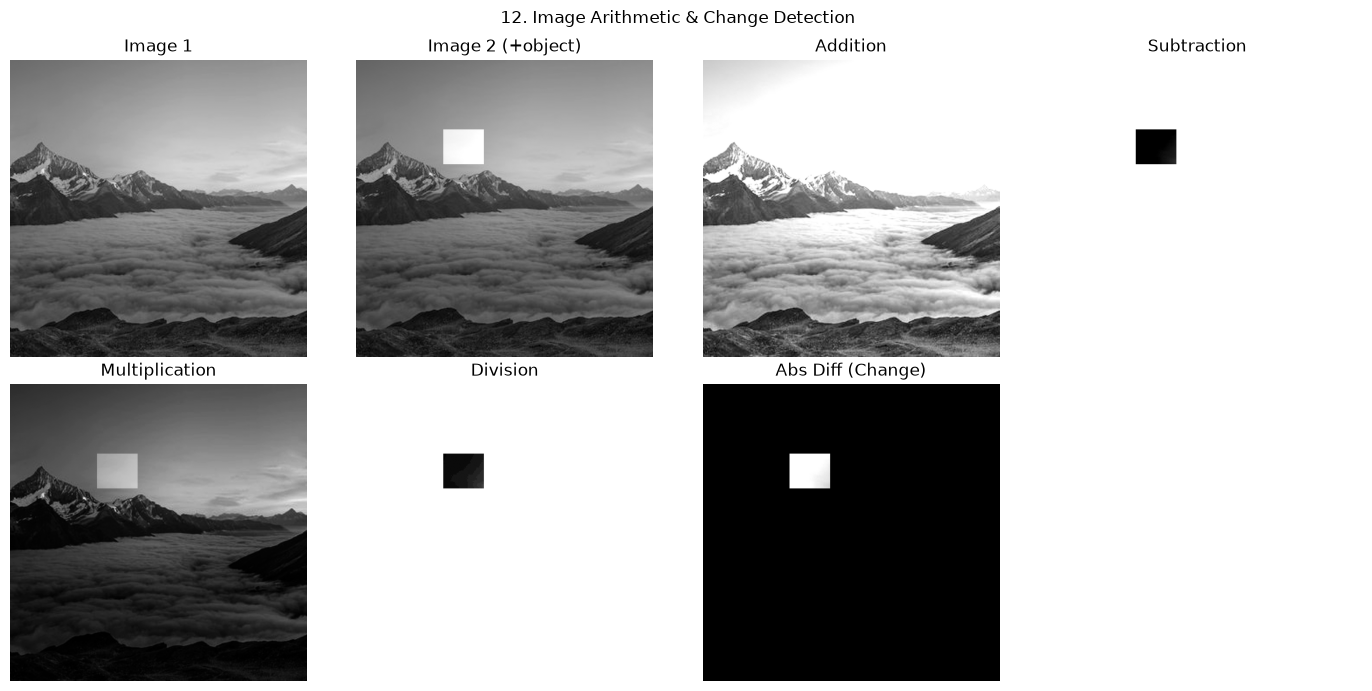

Absolute difference highlights only the changed region.


In [13]:
base = np.array(Image.open(os.path.join(IMG, "nature_gray.png"))).astype(np.float32)
img1 = base.copy()
img2 = base.copy()



img2[120:180, 150:220] = np.clip(img2[120:180, 150:220] + 90, 0, 255)

add  = np.clip(img1 + img2, 0, 255).astype(np.uint8)
sub  = np.clip(img1 - img2 + 128, 0, 255).astype(np.uint8)
mul  = np.clip(img1 * img2 / 255.0, 0, 255).astype(np.uint8)
div  = np.clip(img1 / (img2 + 1e-5) * 64, 0, 255).astype(np.uint8)
diff = np.abs(img1 - img2).astype(np.uint8)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes[0,0].imshow(img1, cmap="gray"); axes[0,0].set_title("Image 1"); axes[0,0].axis("off")
axes[0,1].imshow(img2, cmap="gray"); axes[0,1].set_title("Image 2 (+object)"); axes[0,1].axis("off")
axes[0,2].imshow(add, cmap="gray"); axes[0,2].set_title("Addition"); axes[0,2].axis("off")
axes[0,3].imshow(sub, cmap="gray"); axes[0,3].set_title("Subtraction"); axes[0,3].axis("off")
axes[1,0].imshow(mul, cmap="gray"); axes[1,0].set_title("Multiplication"); axes[1,0].axis("off")
axes[1,1].imshow(div, cmap="gray"); axes[1,1].set_title("Division"); axes[1,1].axis("off")
axes[1,2].imshow(diff, cmap="gray"); axes[1,2].set_title("Abs Diff (Change)"); axes[1,2].axis("off")
axes[1,3].axis("off")
plt.suptitle("12. Image Arithmetic & Change Detection")
plt.tight_layout()
plt.savefig("results/12_arithmetic.png", dpi=120, bbox_inches="tight")
plt.show()
print("Absolute difference highlights only the changed region.")


## 13. Noise Reduction by Image Averaging

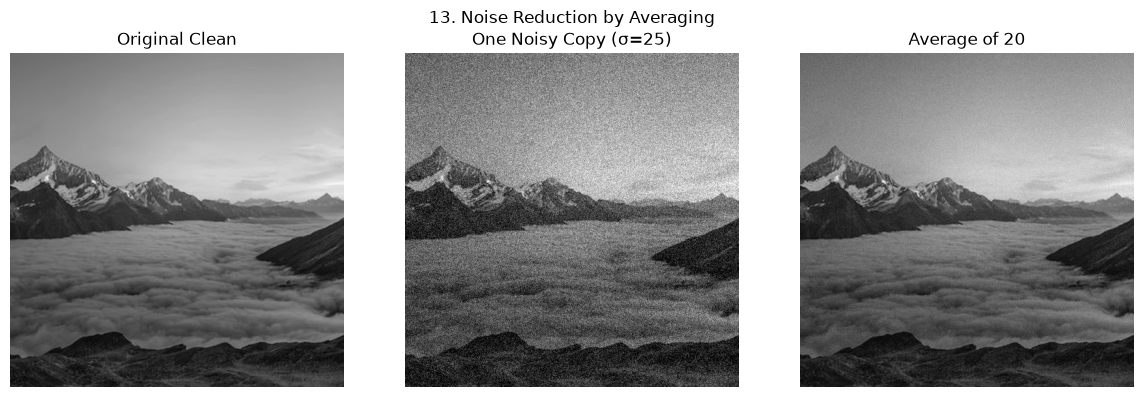

Averaging reduces noise because zero-mean independent Gaussian noise
cancels out (variance decreases ≈ 1/N) while the signal stays.


In [14]:
clean = np.array(Image.open(os.path.join(IMG, "nature_gray.png"))).astype(np.float32)
np.random.seed(42)
noisy_copies = [np.clip(clean + np.random.normal(0, 25, clean.shape), 0, 255) for _ in range(20)]
avg = np.mean(noisy_copies, axis=0).astype(np.uint8)
one_noisy = noisy_copies[0].astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(clean.astype(np.uint8), cmap="gray"); axes[0].set_title("Original Clean"); axes[0].axis("off")
axes[1].imshow(one_noisy, cmap="gray"); axes[1].set_title("One Noisy Copy (σ=25)"); axes[1].axis("off")
axes[2].imshow(avg, cmap="gray"); axes[2].set_title("Average of 20"); axes[2].axis("off")
plt.suptitle("13. Noise Reduction by Averaging")
plt.tight_layout()
plt.savefig("results/13_averaging.png", dpi=120, bbox_inches="tight")
plt.show()
print("""Averaging reduces noise because zero-mean independent Gaussian noise
cancels out (variance decreases ≈ 1/N) while the signal stays.""")


## 14. Set and Logical Operations on Binary Images

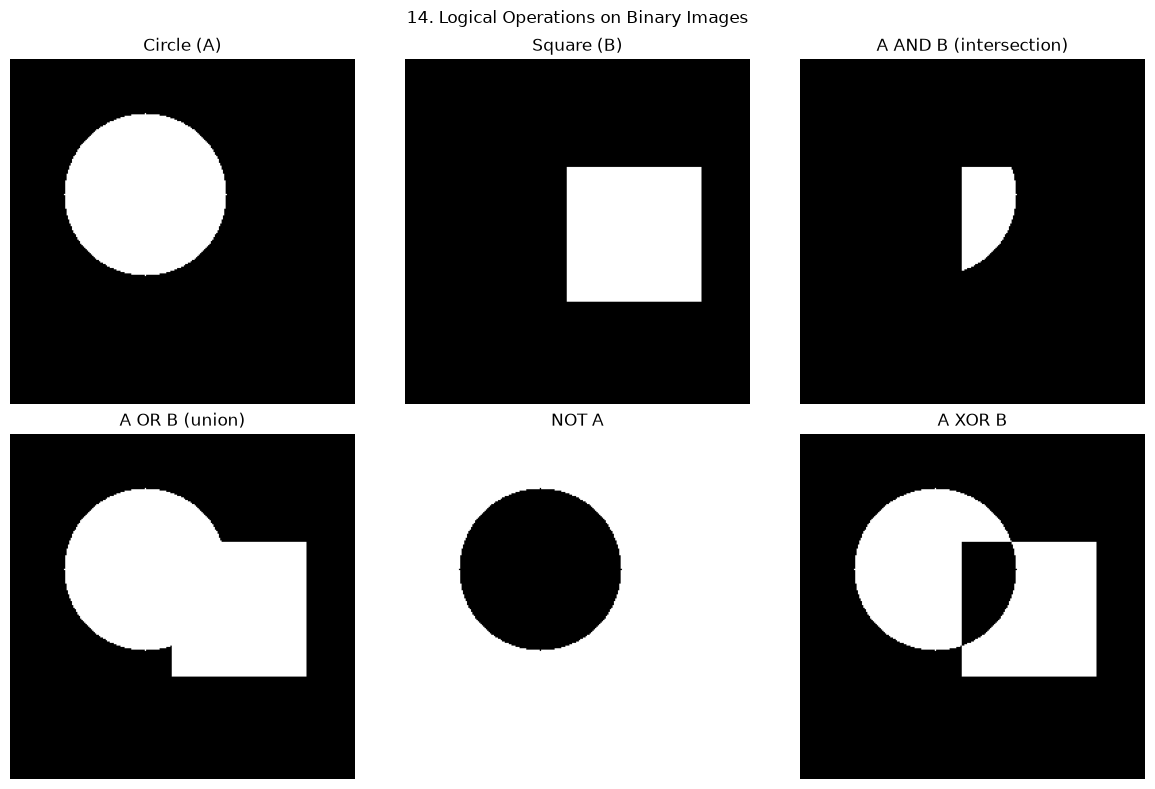

AND = intersection | OR = union | NOT = complement | XOR = symmetric difference


In [15]:
size = 256
circle = np.zeros((size, size), dtype=np.uint8)
yy, xx = np.ogrid[:size, :size]
circle[(xx - 100)**2 + (yy - 100)**2 <= 60**2] = 255

square = np.zeros((size, size), dtype=np.uint8)
square[80:180, 120:220] = 255

and_img = cv2.bitwise_and(circle, square)
or_img  = cv2.bitwise_or(circle, square)
not_img = cv2.bitwise_not(circle)
xor_img = cv2.bitwise_xor(circle, square)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes[0,0].imshow(circle, cmap="gray"); axes[0,0].set_title("Circle (A)"); axes[0,0].axis("off")
axes[0,1].imshow(square, cmap="gray"); axes[0,1].set_title("Square (B)"); axes[0,1].axis("off")
axes[0,2].imshow(and_img, cmap="gray"); axes[0,2].set_title("A AND B (intersection)"); axes[0,2].axis("off")
axes[1,0].imshow(or_img, cmap="gray"); axes[1,0].set_title("A OR B (union)"); axes[1,0].axis("off")
axes[1,1].imshow(not_img, cmap="gray"); axes[1,1].set_title("NOT A"); axes[1,1].axis("off")
axes[1,2].imshow(xor_img, cmap="gray"); axes[1,2].set_title("A XOR B"); axes[1,2].axis("off")
plt.suptitle("14. Logical Operations on Binary Images")
plt.tight_layout()
plt.savefig("results/14_logical.png", dpi=120, bbox_inches="tight")
plt.show()
print("AND = intersection | OR = union | NOT = complement | XOR = symmetric difference")


## 15. Basic Geometric Transformations

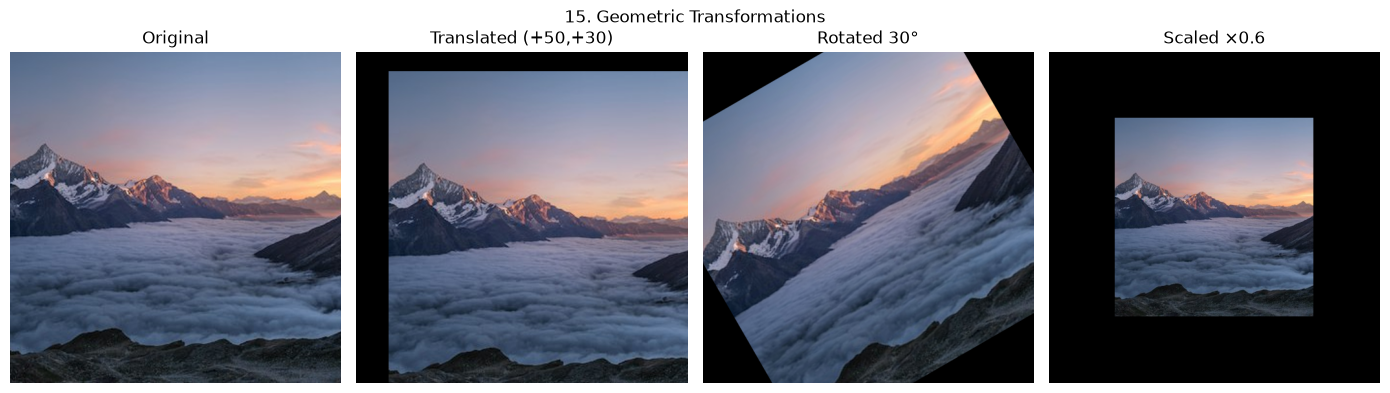

Black regions appear where content is moved outside the frame or scaled away.


In [16]:
src = np.array(Image.open(os.path.join(IMG, "nature_color.png")))
h, w = src.shape[:2]
cx, cy = w // 2, h // 2

# Translation
M_trans = np.float32([[1, 0, 50], [0, 1, 30]])
translated = cv2.warpAffine(src, M_trans, (w, h), borderValue=(0, 0, 0))

# Rotation
M_rot = cv2.getRotationMatrix2D((cx, cy), 30, 1.0)
rotated = cv2.warpAffine(src, M_rot, (w, h), borderValue=(0, 0, 0))

# Scaling
scale = 0.6
new_w, new_h = int(w * scale), int(h * scale)
scaled = cv2.resize(src, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
canvas = np.zeros_like(src)
oy, ox = (h - new_h) // 2, (w - new_w) // 2
canvas[oy:oy+new_h, ox:ox+new_w] = scaled

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(src); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(translated); axes[1].set_title("Translated (+50,+30)"); axes[1].axis("off")
axes[2].imshow(rotated); axes[2].set_title("Rotated 30°"); axes[2].axis("off")
axes[3].imshow(canvas); axes[3].set_title("Scaled ×0.6"); axes[3].axis("off")
plt.suptitle("15. Geometric Transformations")
plt.tight_layout()
plt.savefig("results/15_geometric.png", dpi=120, bbox_inches="tight")
plt.show()
print("Black regions appear where content is moved outside the frame or scaled away.")
